# Thermal Gradient Figures

Setup:
- transducer 0, channel 1 in front of chamber
- transducer 1, channel 2 in back of chamber


In [71]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonicTesting/')
sys.path.append('/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonic_ml/src/')

import pickleJar as pj
import sqliteUtils as squ
import numpy as np
from numpy import fft
import os.path
import matplotlib.pyplot as plt

import pickle

import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from datetime import datetime
import matplotlib.cm as cm

from ultrasonic_ml import gradient_helpers

plt.clf()
plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 16,
        'figure.dpi': 300,
        'savefig.dpi': 300,
    })

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<Figure size 1920x1440 with 0 Axes>

## Import Data

### exp set 1

In [72]:
# First we load the data from the file we want to analyze
# The experiment should always output sqlite3 files, so let's convert them to a more usable pickle form first
# sqliteFiles = [
#     '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/lmfp_cu_mux_control_20C1784034697.sqlite3',
#     '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/stability_10C.sqlite3'
#                ]

# monitor_file_path_list = [
#     '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/CoSo_2026-07-14_16-12-28_Monitor.csv',
#     '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/CoSo_2026-07-15_10-26-16_Monitor.csv'
# ]


### exp set 2

In [73]:
sqliteFiles = [
    # '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/stability_ramp_down_20C/stability_20C1784564266.sqlite3',
    '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/stability_ramp_down_20C/stability_20C1784572516.sqlite3',
    '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/gradient_19C_22C/gradient_19_22C1784580883.sqlite3',
    '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/gradient_18C_24C/gradient_18_24C.sqlite3',
    '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/gradient_17C_26C/repaired.sqlite3',
    '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/gradient_16C_28C/gradient_16_28C.sqlite3',
    # '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/stability_20C_chamber_min/stability_20C_chamber_min.sqlite3'

                ]

monitor_file_path_list = [
    '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/stability_ramp_down_20C/CoSo_2026-07-20_13-56-51_Monitor.csv',
    '/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/stability_20C_chamber_min/CoSo_2026-07-21_10-10-00_Monitor.csv'                          
    ]

settings_file_path_list = [monitor_file_path.replace('_Monitor.csv', '_Settings.csv') for monitor_file_path in monitor_file_path_list]


### merge load pickles

In [74]:
# Convert the sqlite3 to a .pickle
# This takes a few seconds. A progress bar will display in your terminal
pj.multiSqliteToPickle(sqliteFiles)


# Load the pickle
pickleFiles = [os.path.splitext(sqliteFile)[0] + '.pickle' for sqliteFile in sqliteFiles]
data = gradient_helpers.stitch_interp_normalize_pickles(pickleFiles, 
                                       saveName='combined.pickle', 
                                       save_directory='/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing', 
                                       num_points=2500, 
                                       overwrite=True)
# data = pj.combineRepeatPulseData([pj.loadPickle(pickle_) for pickle_ in pickleFiles], 
#                           saveName='combined.pickle')


# data = pj.loadPickle(os.path.split(pickleFiles[0])[0]+'/combined.pickle')
# data['parameters']['dt'] = data['parameters']['measureTime']-data['parameters']['measureDelay'] *10-6/ data['parameters']['samples']


Converting /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/stability_ramp_down_20C/stability_20C1784572516.sqlite3

sqliteToPickle Warning: pickle file /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/stability_ramp_down_20C/stability_20C1784572516.pickle already exists. Conversion aborted.

Converting /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/gradient_19C_22C/gradient_19_22C1784580883.sqlite3

sqliteToPickle Warning: pickle file /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing/gradient_19C_22C/gradient_19_22C1784580883.pickle already exists. Conversion aborted.

Converting /Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang 

In [ ]:
data.keys()

### Merge the waveform and controller data wrt time that UT is running

In [75]:
merged_df = gradient_helpers.load_and_merge_to_data_df(data, 
                                                       monitor_file_path_list, 
                                                       settings_file_path_list,
                                                       saveName='merged_df.pickle',
                                                       save_directory='/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/temperature testing',
                                                       overwrite=True)
merged_df.tail()

/Users/xz498/Library/CloudStorage/OneDrive-DrexelUniversity/Chang Lab - Documents/General/Individual/Xinqiao Zhang/data_analysis/ultrasonic_ml/src/ultrasonic_ml/gradient_helpers.py:173: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['Time_str'] = pd.to_datetime(merged_df['Time_str']).dt.strftime('%m/%d/%y %H:%M:%S')


,voltage_transmission_forward,voltage_transmission_reverse,time,time_collected,collection_index,exp_idx,Time,1000.1: CH1 Object,1000.2: CH2 Object,1001.1: CH1 Sink,...,105.1: Error Number,106.1: Error Inst,107.1: Error Param,1200.1: Temperature is Stable,1200.2: Temperature is Stable,2010.1: Output Enable,2010.2: Output Enable,3034.1: Peltier Polarity,3034.2: Peltier Polarity,Time_str
23240,"[-0.0334026028331082, -0.033528859991585794, -...","[-0.032117328106468376, -0.032117328106468376,...","[1500.0, 1502.0, 1504.0, 1506.0, 1508.0, 1510....",1.784605e+09,1819.0,4,1.784605e+09,19.370844,19.632135,20.019770,...,182,1,16437,0,0,ON,ON,Cooling,Cooling,07/20/26 23:42:48
23241,"[-0.03327142483260927, -0.03289265178123621, -...","[-0.03200212936328371, -0.03174921662078101, -...","[1500.0, 1502.0, 1504.0, 1506.0, 1508.0, 1510....",1.784605e+09,1820.0,4,1.784605e+09,19.367517,19.626184,20.008051,...,182,1,16437,0,0,ON,ON,Cooling,Cooling,07/20/26 23:42:49
23242,"[-0.03317316718243685, -0.033046995770680404, ...","[-0.03118800879091934, -0.03118800879091934, -...","[1500.0, 1502.0, 1504.0, 1506.0, 1508.0, 1510....",1.784605e+09,1821.0,4,1.784605e+09,19.359491,19.620203,19.996149,...,182,1,16437,0,0,ON,ON,Cooling,Cooling,07/20/26 23:42:50
23243,"[-0.033014048115062984, -0.03314019067260091, ...","[-0.03213802220982785, -0.031252488733983806, ...","[1500.0, 1502.0, 1504.0, 1506.0, 1508.0, 1510....",1.784605e+09,1822.0,4,1.784605e+09,19.350580,19.614588,19.983454,...,182,1,16437,0,0,ON,ON,Cooling,Cooling,07/20/26 23:42:51
23244,"[-0.03330882614094451, -0.033435062335837346, ...","[-0.0314843455861644, -0.0323701310406774, -0....","[1500.0, 1502.0, 1504.0, 1506.0, 1508.0, 1510....",1.784605e+09,1823.0,4,1.784605e+09,19.346399,19.609919,19.972437,...,182,1,16437,0,0,ON,ON,Cooling,Cooling,07/20/26 23:42:52


### calculate tof and amplitudes

In [76]:
merged_df = gradient_helpers.calculate_mean_diff(merged_df)
merged_df = gradient_helpers.calculate_waveform_features(merged_df)

In [ ]:
merged_df.tail()

## Visualize

### raw waveforms

In [ ]:
gradient_helpers.plot_waveform(0, merged_df=merged_df, max_=merged_df['max_forward (mV)'].max())

### Experimental conditions v amplitude and tof

In [ ]:
merged_df[['1000.1: CH1 Object', '1000.2: CH2 Object', '1044.3: LR3 Temp']].values.min()

In [ ]:
gradient_helpers.plot_experimental_data(i=0, keys_=(), df=merged_df, idx_label_type='time', 
                                        x_scaling='collection_time')

### Subtract out overal trends in amplitude and tof

In [ ]:
## todo

In [ ]:
# # detrend/interactive visualizer

# df = merged_df.iloc[1500:]
# df = detrend_filtered_data(df)

# def run_plotter(i=0, keys_=()): plot_temps(i=i, keys_=list(keys_), idx_lable_type='dT')

# slider = widgets.IntSlider(
#     value=0,
#     min=0,
#     max=len(df)-1,
#     step=1,
#     description='measurement:',
#     continuous_update=False
# )

# selected_keys = [col for col in df.columns if col.startswith(('Simple_ToF', 'Hilbert_ToF', 'amplitude'))]
# selected_keys.sort()
# keys = widgets.SelectMultiple(
#     options=selected_keys,
#     value=tuple([]),
#     description='Variable:',
#     disabled=False,
# )

# interact(lambda i, key_: run_plotter(i=i, keys_=list(key_)), i=slider, key_=keys)

### Filter out outliers (+/- 0.25 from target)

In [ ]:
merged_df

In [77]:
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets
from datetime import datetime

# calculate mask
mask = ( (merged_df['1000.1: CH1 Object'] - merged_df['3000.1: CH1 Target']).abs() < 0.25  
   ) & ( (merged_df['1000.2: CH2 Object'] - merged_df['3000.2: CH2 Target']).abs() < 0.25 )

# detrend after 1500 bc that is when gradient exp starts
# merged_df.iloc[1500:] = detrend_filtered_data(merged_df.iloc[1500:])

# filter
merged_filtered_df = merged_df.loc[mask].copy().reset_index(drop=True)

In [78]:
gradient_helpers.plot_experimental_data(i=0, keys_=(), df=merged_filtered_df, idx_label_type='time', 
                                        x_scaling='collection_time')

interactive(children=(IntSlider(value=0, continuous_update=False, description='measurement:', layout=Layout(wi…

## plot mean + stdv tof and amplitudes against temperature

### avg

https://www.mdpi.com/1424-8220/25/2/385 this article uses 2nd order polynomial on speed of sound. But our amplitude was the polynoial like fit


In [145]:
# fit means and tof
import matplotlib.pyplot as plt

temps =[20. , 20.5, 21. , 21.5]
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []
f_hilbert_tof_arr, f_hilbert_tof_err = [], []
r_hilbert_tof_arr, r_hilbert_tof_err = [], []

# for i in temps:
#     mask =  (merged_filtered_df['3000.1: CH1 Target'] == i) & \
#             (merged_filtered_df['3000.2: CH2 Target'] == i) & \
#             (merged_filtered_df.index < 740)
for i in range(4):
    mask = (
        (merged_filtered_df['3000.1: CH1 Target'] == 20 - i)
        & (merged_filtered_df['3000.2: CH2 Target'] == 20 + 2*i)
        # & (merged_filtered_df['2010.1: Output Enable'] == 'ON')
        # & (merged_filtered_df['2010.2: Output Enable'] == 'ON')
        # & (merged_filtered_df.index > 755)
    )    
    filtered_df = merged_filtered_df[mask]
    if filtered_df.empty: 
        print(i)
        continue
    
    f_amp_arr.append(filtered_df[f'amplitude_forward (mV)'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward (mV)'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse (mV)'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse (mV)'].std())
    
    # f_simple_tof_arr.append(filtered_df[f'Simple_ToF_forward (ns)'].mean())
    # f_simple_tof_err.append(filtered_df[f'Simple_ToF_forward (ns)'].std())
    
    # r_simple_tof_arr.append(filtered_df[f'Simple_ToF_reverse (ns)'].mean())
    # r_simple_tof_err.append(filtered_df[f'Simple_ToF_reverse (ns)'].std())
    
    f_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_forward (ns)'].mean())
    f_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_forward (ns)'].std())
    
    r_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].mean())
    r_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].std())
    
# f_amp_fit = np.polyfit(temps, f_amp_arr, 2)
# f_amp_fit = f_amp_fit[0] * np.array(temps)**2 + f_amp_fit[1] * np.array(temps) + f_amp_fit[2]
# r_amp_fit = np.polyfit(temps, r_amp_arr, 2)
# r_amp_fit = r_amp_fit[0] * np.array(temps)**2 + r_amp_fit[1] * np.array(temps) + r_amp_fit[2]
f_amp_params = np.polyfit(temps, f_amp_arr, 1)
f_amp_fit = f_amp_params[0] * np.array(temps) + f_amp_params[1]
r_amp_params = np.polyfit(temps, r_amp_arr, 1)
r_amp_fit = r_amp_params[0] * np.array(temps) + r_amp_params[1]
f_amp_residuals = f_amp_arr - f_amp_fit
r_amp_residuals = r_amp_arr - r_amp_fit

# f_simple_tof_fit = np.polyfit(temps, f_simple_tof_arr, 1)
# f_simple_tof_fit = f_simple_tof_fit[0] * np.array(temps) + f_simple_tof_fit[1]
# r_simple_tof_fit = np.polyfit(temps, r_simple_tof_arr, 1)
# r_simple_tof_fit = r_simple_tof_fit[0] * np.array(temps) + r_simple_tof_fit[1]
# f_simple_tof_residuals = f_simple_tof_arr - f_simple_tof_fit
# r_simple_tof_residuals = r_simple_tof_arr - r_simple_tof_fit

# f_hilbert_tof_fit = np.polyfit(temps, f_hilbert_tof_arr, 1)
# f_hilbert_tof_fit = f_hilbert_tof_fit[0] * np.array(temps) + f_hilbert_tof_fit[1]
# r_hilbert_tof_fit = np.polyfit(temps, r_hilbert_tof_arr, 1)
# r_hilbert_tof_fit = r_hilbert_tof_fit[0] * np.array(temps) + r_hilbert_tof_fit[1]
# r_hilbert_tof_residuals = r_hilbert_tof_arr - r_hilbert_tof_fit

f_hilbert_params = np.polyfit(temps, f_hilbert_tof_arr, 1)
f_hilbert_fit = f_hilbert_params[0] * np.array(temps) + f_hilbert_params[1]
r_hilbert_params = np.polyfit(temps, r_hilbert_tof_arr, 1)
r_hilbert_fit = r_hilbert_params[0] * np.array(temps) + r_hilbert_params    [1]
f_hilbert_residuals = f_hilbert_tof_arr - f_hilbert_fit

r_hilbert_residuals = r_hilbert_tof_arr - r_hilbert_fit


In [146]:
temps

[20.0, 20.5, 21.0, 21.5]

In [147]:
f_amp_fit

array([1.80624586, 1.82165868, 1.83707149, 1.85248431])

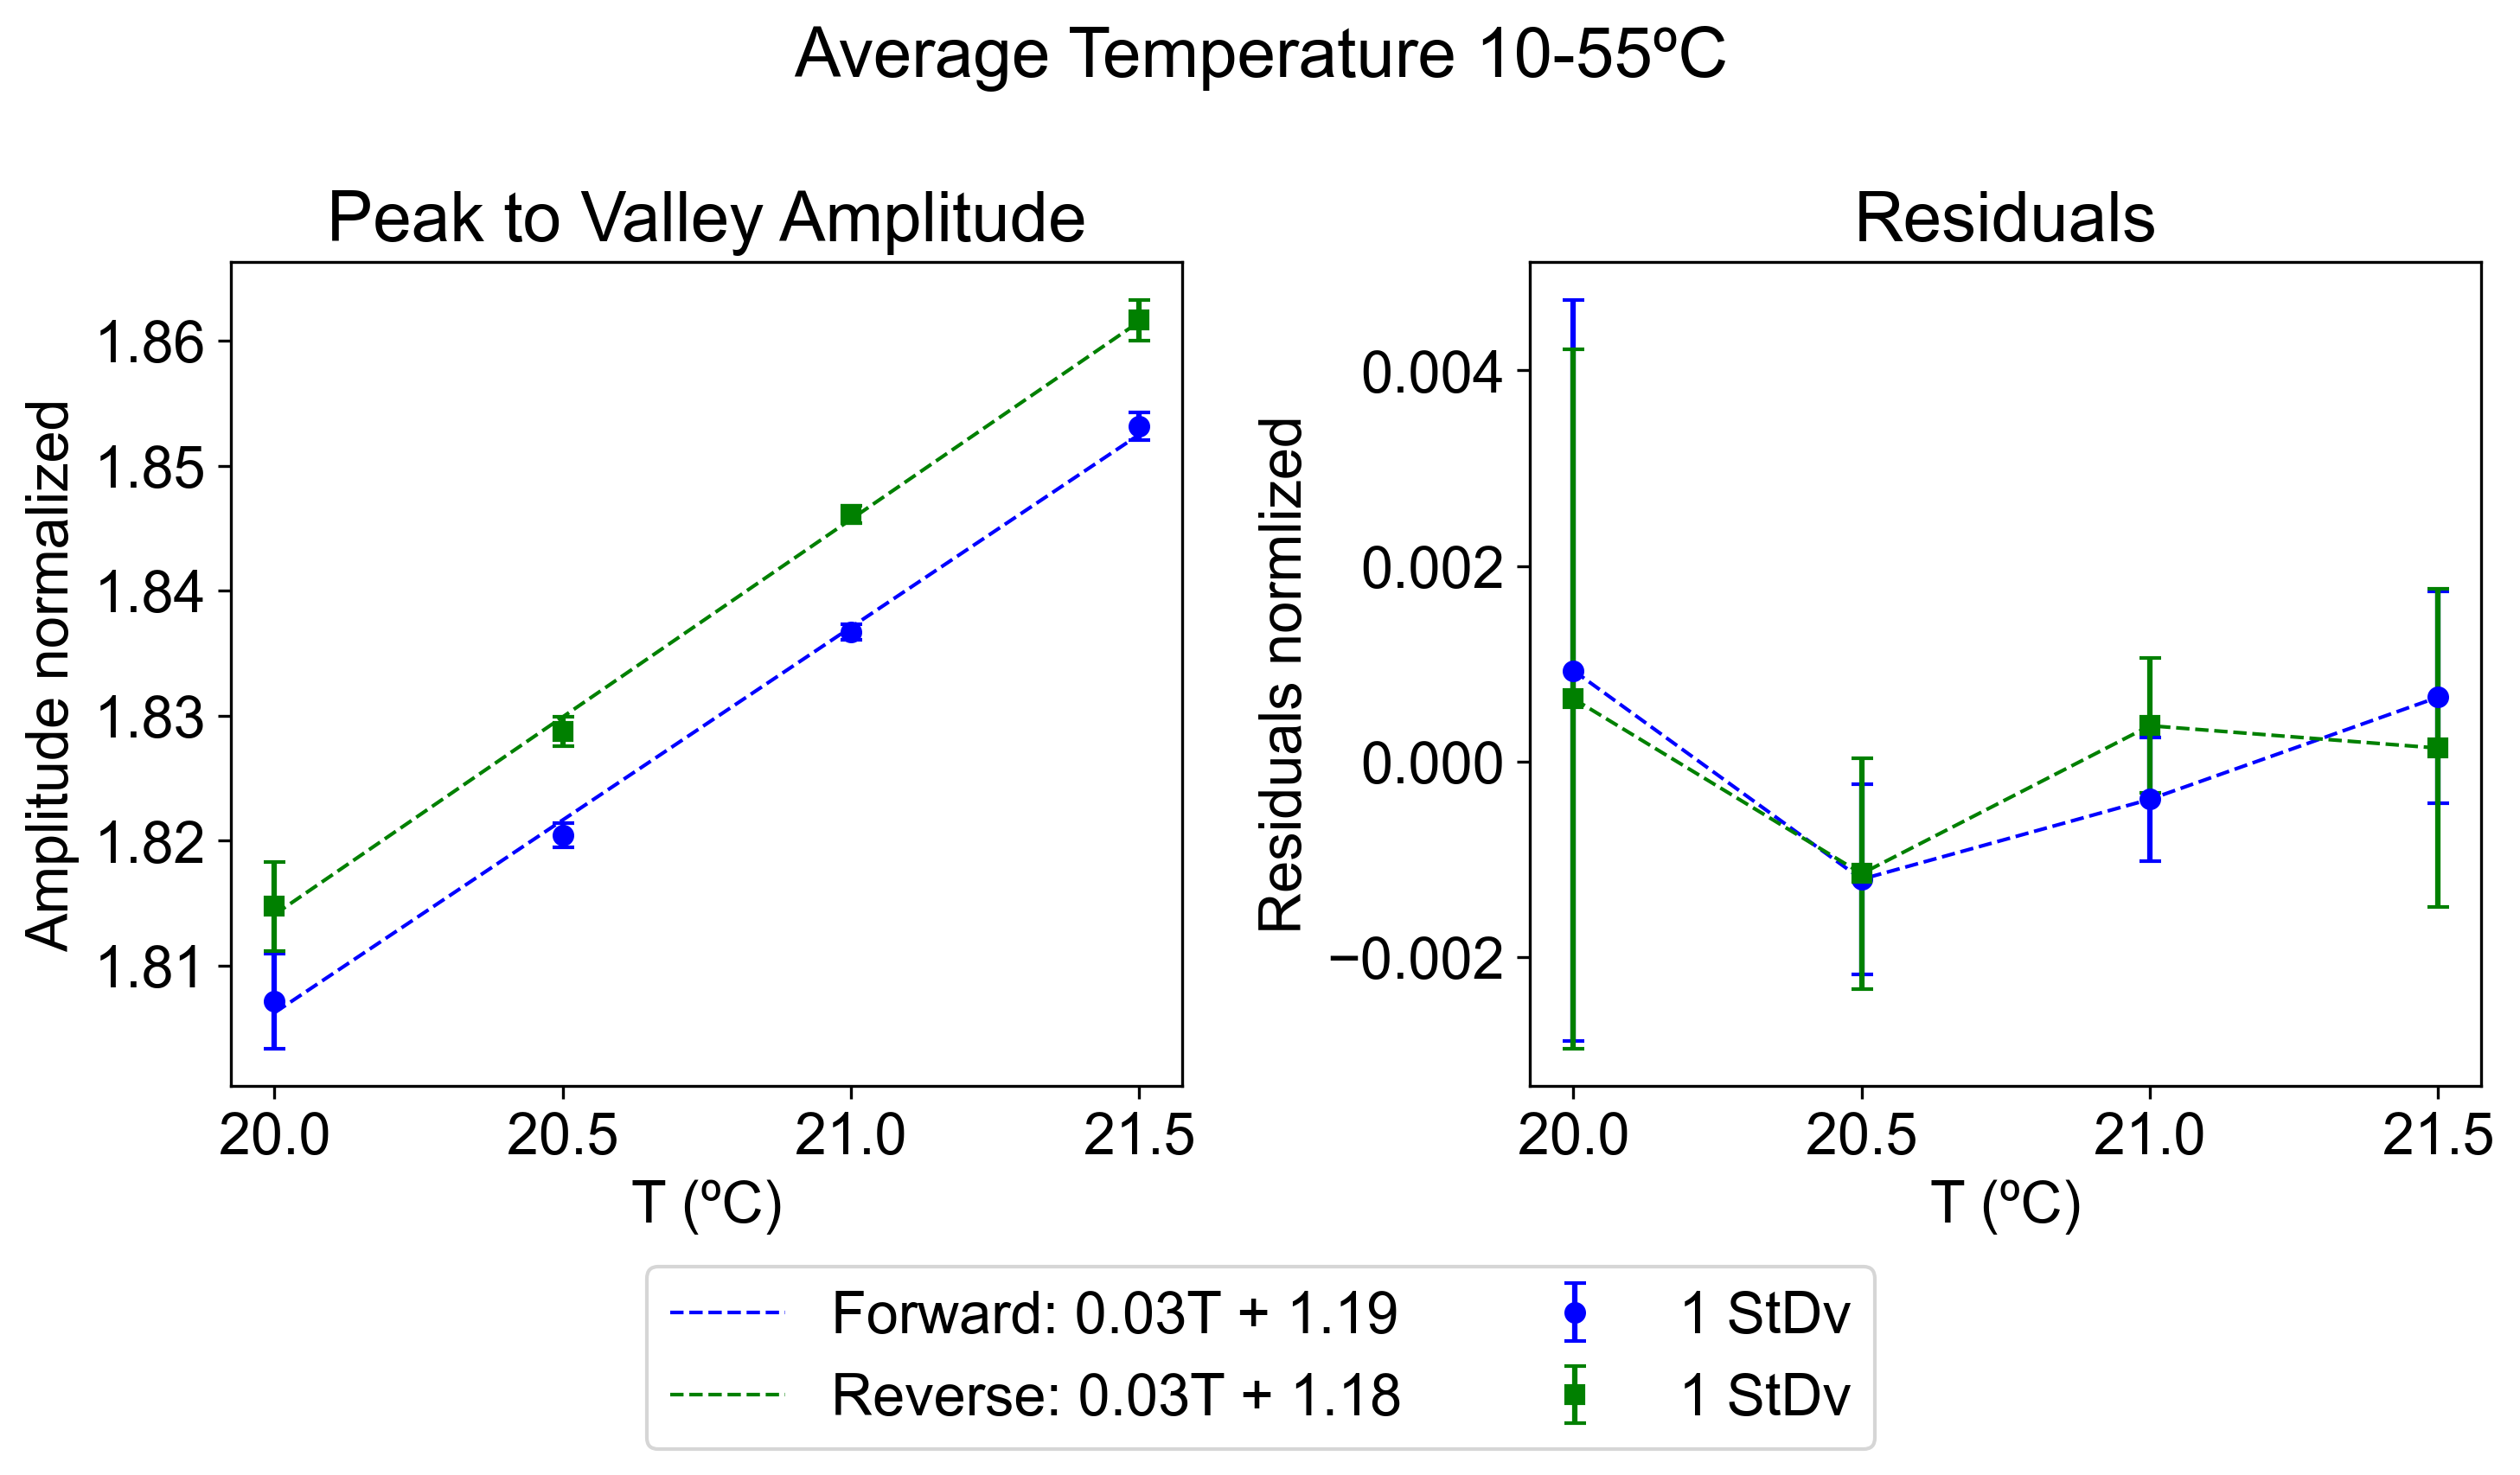

In [148]:
# plot amplitudes
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Average Temperature 10-55ºC')

# ax[0].plot(temps, f_amp_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_amp_fit[0]:.2f}T^2 + {f_amp_fit[1]:.2f}T + {f_amp_fit[2]:.2f}')
ax[0].plot(temps, f_amp_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_amp_params[0]:.2f}T + {f_amp_params[1]:.2f}')
ax[0].errorbar(temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
# ax[0].plot(temps, r_amp_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_amp_fit[0]:.2f}T^2 + {r_amp_fit[1]:.2f}T + {r_amp_fit[2]:.2f}')
ax[0].plot(temps, r_amp_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_amp_params[0]:.2f}T + {r_amp_params[1]:.2f}')
ax[0].errorbar(temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('Peak to Valley Amplitude')
ax[0].set_xlabel('T (ºC)')
ax[0].set_ylabel('Amplitude normalized')

ax[1].plot(temps, f_amp_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(temps, f_amp_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(temps, r_amp_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(temps, r_amp_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('T (ºC)')
ax[1].set_ylabel('Residuals normlized')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

In [ ]:
for t in np.array([20,20.5,22,22.5]):
    print(f'asymmetric:{1.81*t+1.82:.2f},\t isothermal: {1.83*t**2+1.91*t +1.96:.2f}')


asymmetric:38.02,	 isothermal: 772.16
asymmetric:38.93,	 isothermal: 810.17
asymmetric:41.64,	 isothermal: 929.70
asymmetric:42.55,	 isothermal: 971.37


In [ ]:
# fig, ax = plt.subplots(1,2, figsize=(10,5))
# fig.suptitle('Average Temperature 10-55ºC')

# ax[0].plot(temps, f_simple_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_simple_tof_fit[0]:.2f}T + {f_simple_tof_fit[1]:.2f} (ns)')
# ax[0].errorbar(temps, f_simple_tof_arr, yerr=f_simple_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
# ax[0].plot(temps, r_simple_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_simple_tof_fit[0]:.2f}T + {r_simple_tof_fit[1]:.2f} (ns)')
# ax[0].errorbar(temps, r_simple_tof_arr, yerr=r_simple_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
# ax[0].set_title('15% threshold ToF')
# ax[0].set_xlabel('T (ºC)')
# ax[0].set_ylabel('ToF (ns)' )

# ax[1].plot(temps, f_simple_tof_residuals, color='blue', linewidth=1, linestyle='--')
# ax[1].errorbar(temps, f_simple_tof_residuals, yerr=f_simple_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
# ax[1].plot(temps, r_simple_tof_residuals, color='green', linewidth=1, linestyle='--',)
# ax[1].errorbar(temps, r_simple_tof_residuals, yerr=r_simple_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
# ax[1].set_title('Residuals')
# ax[1].set_xlabel('T (ºC)')
# ax[1].set_ylabel('ToF (ns) Residuals')

# fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

# fig.tight_layout()

In [ ]:
# plot hilbert window tof
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Average Temperature 10-55ºC')

ax[0].plot(temps, f_hilbert_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_hilbert_tof_fit[0]:.2f}T + {f_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(temps, f_hilbert_tof_arr, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(temps, r_hilbert_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_hilbert_tof_fit[0]:.2f}T + {r_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(temps, r_hilbert_tof_arr, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% Hilbert Window ToF')
ax[0].set_xlabel('T (ºC)')
ax[0].set_ylabel('ToF (ns)' )

ax[1].plot(temps, f_hilbert_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(temps, f_hilbert_tof_residuals, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(temps, r_hilbert_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(temps, r_hilbert_tof_residuals, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('T (ºC)')
ax[1].set_ylabel('ToF (ns) Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

### dt

In [ ]:
merged_filtered_df

In [149]:
# calculate trends and detrended data for dT experiments
import matplotlib.pyplot as plt
d_temps = range(0, 12, 3)
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []
f_simple_tof_arr, f_simple_tof_err = [], []
r_simple_tof_arr, r_simple_tof_err = [], []
f_hilbert_tof_arr, f_hilbert_tof_err = [], []
r_hilbert_tof_arr, r_hilbert_tof_err = [], []

for i in range(4):
    mask = (
        (merged_filtered_df['3000.1: CH1 Target'] == 20 - i)
        & (merged_filtered_df['3000.2: CH2 Target'] == 20 + 2*i)
        # & (merged_filtered_df['2010.1: Output Enable'] == 'ON')
        # & (merged_filtered_df['2010.2: Output Enable'] == 'ON')
        # & (merged_filtered_df.index > 755)
    )
    filtered_df = merged_filtered_df[mask]
    if filtered_df.empty: 
        print(i)
        continue
    
    f_amp_arr.append(filtered_df[f'amplitude_forward (mV)'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward (mV)'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse (mV)'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse (mV)'].std())
    
    # f_simple_tof_arr.append(filtered_df[f'Simple_ToF_forward (ns)'].mean())
    # f_simple_tof_err.append(filtered_df[f'Simple_ToF_forward (ns)'].std())
    
    # r_simple_tof_arr.append(filtered_df[f'Simple_ToF_reverse (ns)'].mean())
    # r_simple_tof_err.append(filtered_df[f'Simple_ToF_reverse (ns)'].std())
    
    f_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_forward (ns)'].mean())
    f_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_forward (ns)'].std())
    
    r_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].mean())
    r_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].std())
    
f_amp_params = np.polyfit(d_temps, f_amp_arr, 1)
f_amp_fit = f_amp_params[0] * np.array(d_temps) + f_amp_params[1]
r_amp_params = np.polyfit(d_temps, r_amp_arr, 1)
r_amp_fit = r_amp_params[0] * np.array(d_temps) + r_amp_params[1]
f_amp_residuals = f_amp_arr - f_amp_fit
r_amp_residuals = r_amp_arr - r_amp_fit

# f_simple_tof_fit = np.polyfit(d_temps, f_simple_tof_arr, 1)
# f_simple_tof_fit = f_simple_tof_fit[0] * np.array(d_temps) + f_simple_tof_fit[1]
# r_simple_tof_fit = np.polyfit(d_temps, r_simple_tof_arr, 1)
# r_simple_tof_fit = r_simple_tof_fit[0] * np.array(d_temps) + r_simple_tof_fit[1]
# f_simple_tof_residuals = f_simple_tof_arr - f_simple_tof_fit
# r_simple_tof_residuals = r_simple_tof_arr - r_simple_tof_fit

f_hilbert_tof_params = np.polyfit(d_temps, f_hilbert_tof_arr, 1)
f_hilbert_tof_fit = f_hilbert_tof_params[0] * np.array(d_temps) + f_hilbert_tof_params[1]
r_hilbert_tof_params = np.polyfit(d_temps, r_hilbert_tof_arr, 1)
r_hilbert_tof_fit = r_hilbert_tof_params[0] * np.array(d_temps) + r_hilbert_tof_params[1]
f_hilbert_tof_residuals = f_hilbert_tof_arr - f_hilbert_tof_fit
r_hilbert_tof_residuals = r_hilbert_tof_arr - r_hilbert_tof_fit

In [150]:
f_amp_fit

array([1.80624586, 1.82165868, 1.83707149, 1.85248431])

In [151]:
list(d_temps)

[0, 3, 6, 9]

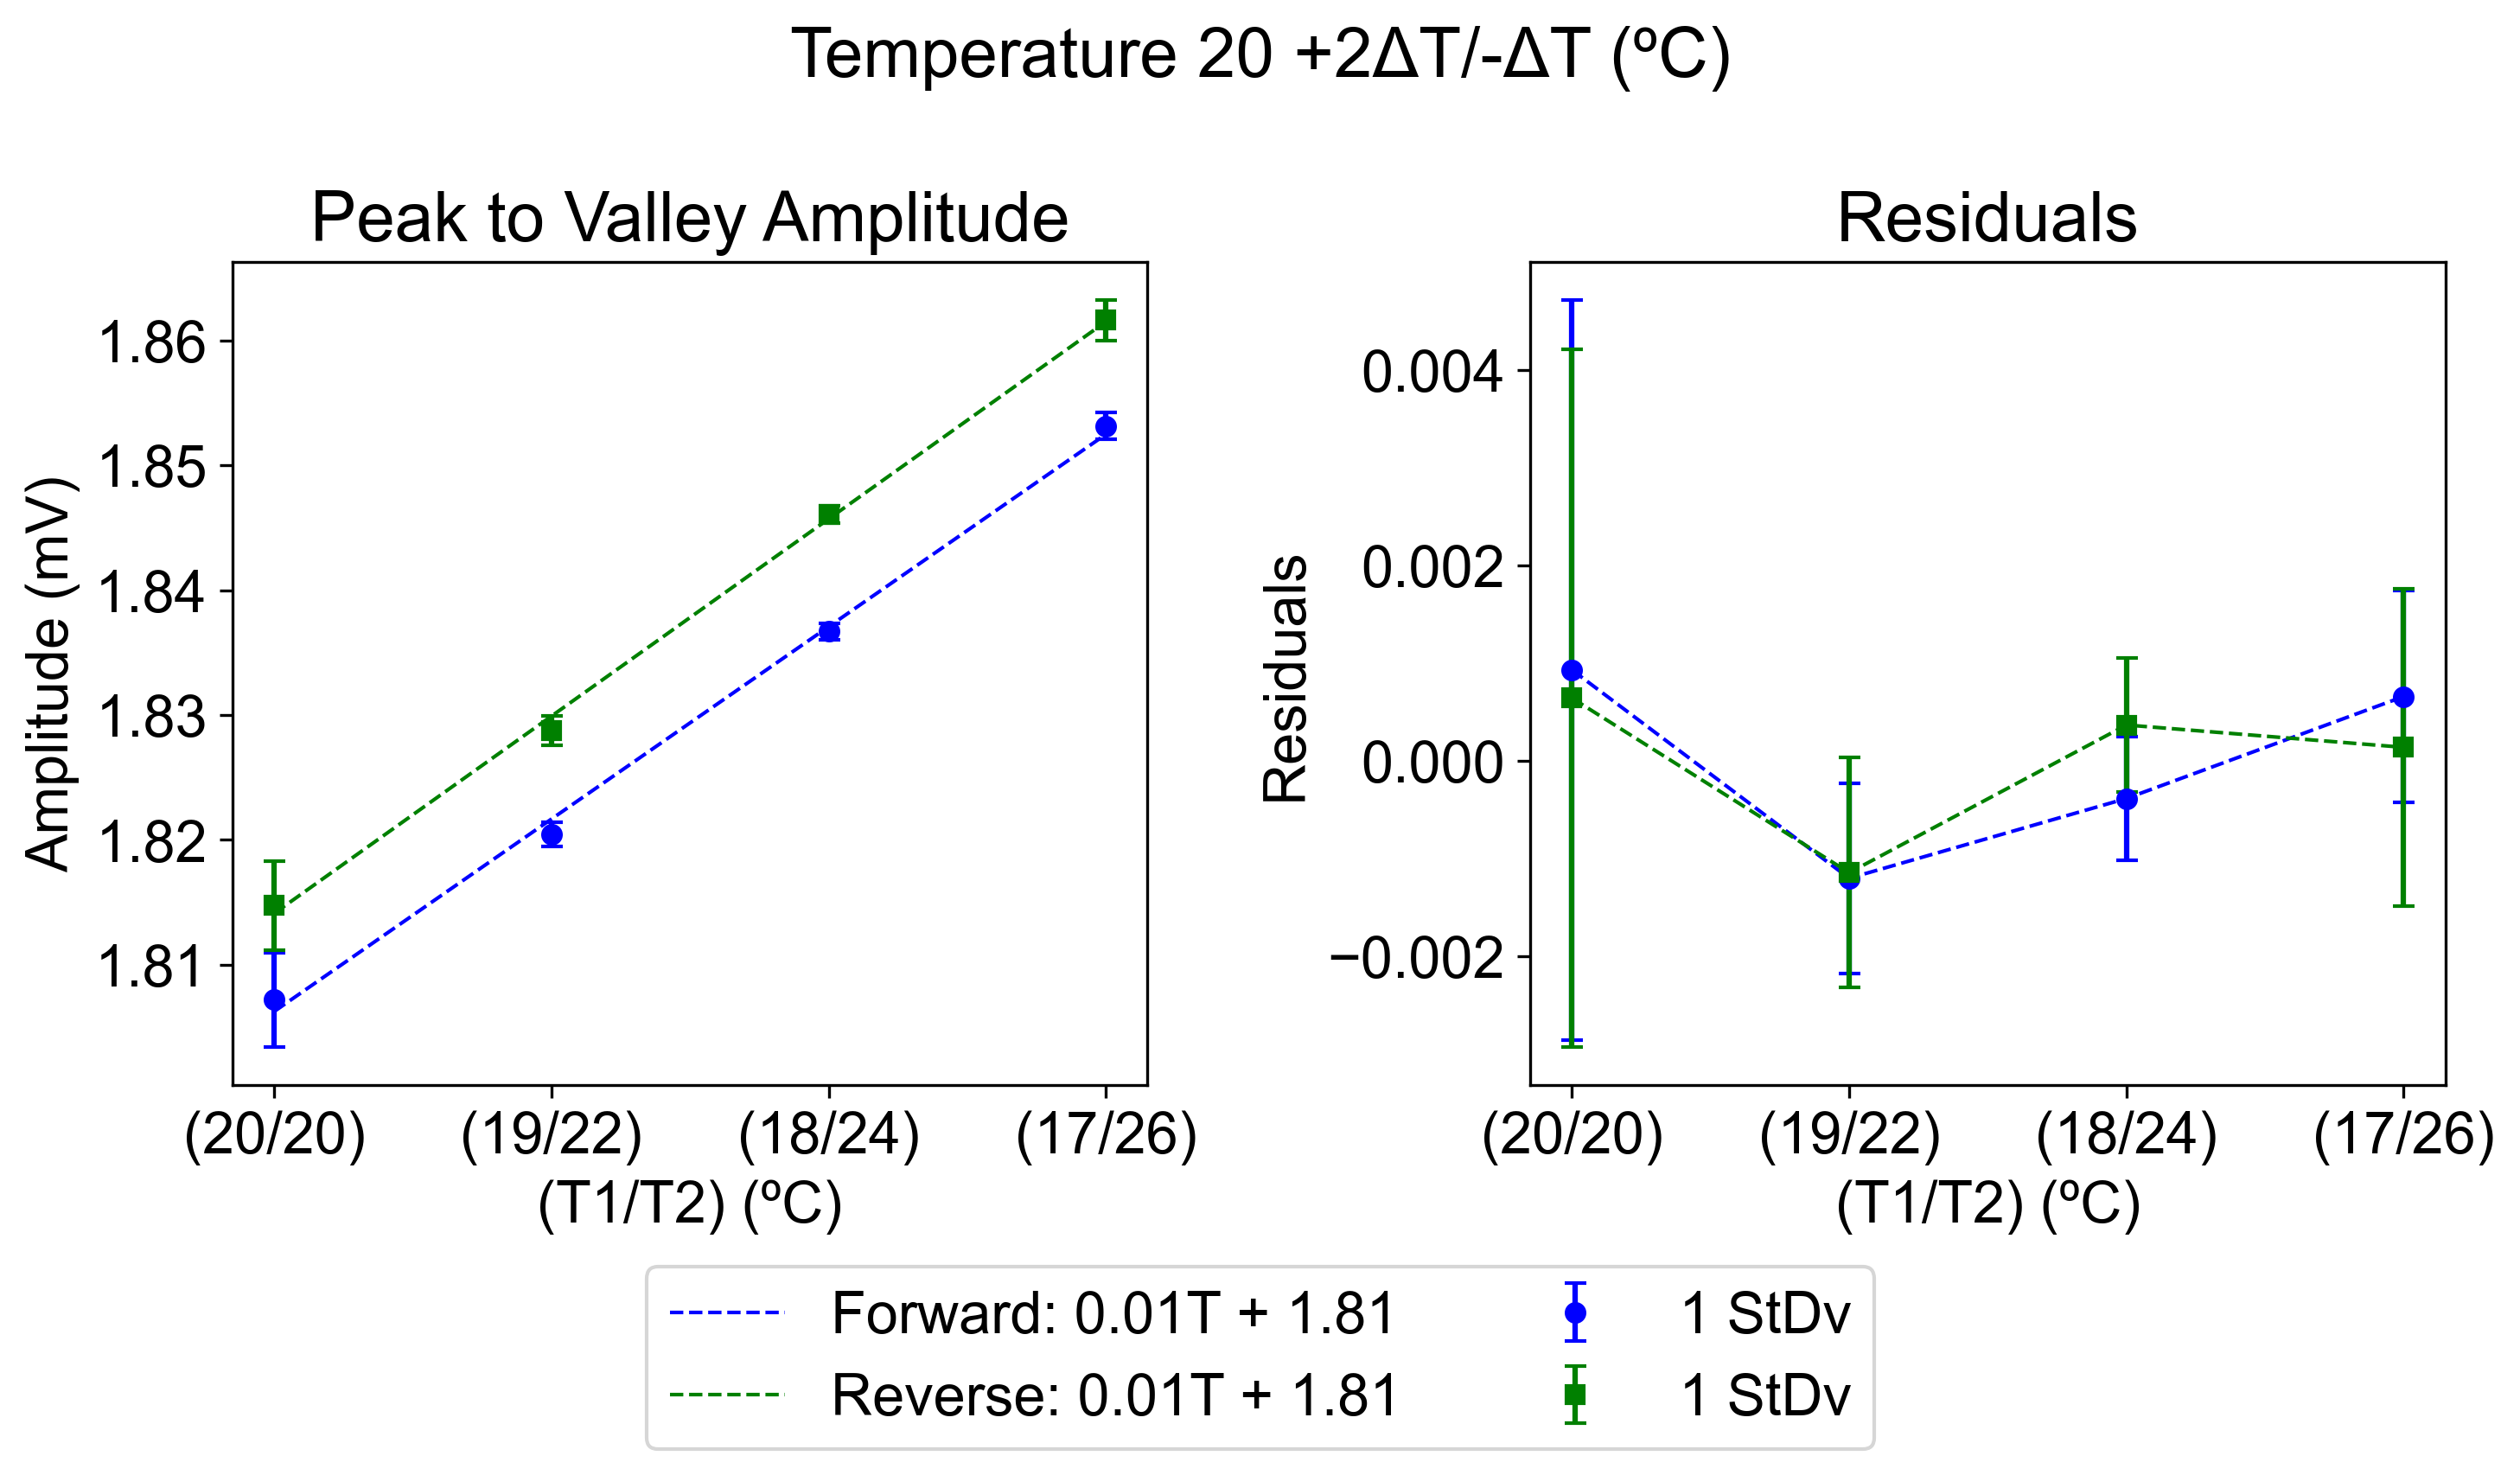

In [152]:
# plot amplitude
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 20 +2ΔT/-ΔT (ºC)')

x_ticks = [f'({20-i}/{20+2*i})' for i in range(4)]


ax[0].plot(d_temps, f_amp_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_amp_params[0]:.2f}T + {f_amp_params[1]:.2f}')
ax[0].errorbar(d_temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_amp_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_amp_params[0]:.2f}T + {r_amp_params[1]:.2f}')
ax[0].errorbar(d_temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('Peak to Valley Amplitude')
ax[0].set_xlabel('(T1/T2) (ºC)')
ax[0].set_xticks(ticks=d_temps, labels=x_ticks)
ax[0].set_ylabel('Amplitude (mV)')

ax[1].plot(d_temps, f_amp_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_amp_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_amp_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_amp_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('(T1/T2) (ºC)')
ax[1].set_xticks(ticks=d_temps, labels=x_ticks)
ax[1].set_ylabel('Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

In [84]:
for t in np.array([20,20.5,22,22.5]):
    print(f'asymmetric:{1.81*t+1.82:.2f},\t isothermal: {1.83*t**2+1.91*t +1.96:.2f}')


asymmetric:38.02,	 isothermal: 772.16
asymmetric:38.93,	 isothermal: 810.17
asymmetric:41.64,	 isothermal: 929.70
asymmetric:42.55,	 isothermal: 971.37


In [ ]:
# # plot simple tof
# fig, ax = plt.subplots(1,2, figsize=(10,5))
# fig.suptitle('Average Temperature 10-55ºC')

# ax[0].plot(d_temps, f_simple_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_simple_tof_fit[0]:.2f}T + {f_simple_tof_fit[1]:.2f} (ns)')
# ax[0].errorbar(d_temps, f_simple_tof_arr, yerr=f_simple_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
# ax[0].plot(d_temps, r_simple_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_simple_tof_fit[0]:.2f}T + {r_simple_tof_fit[1]:.2f} (ns)')
# ax[0].errorbar(d_temps, r_simple_tof_arr, yerr=r_simple_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
# ax[0].set_title('15% threshold ToF')
# ax[0].set_xlabel('ΔT (ºC)')
# ax[0].set_ylabel('ToF (ns)' )

# ax[1].plot(d_temps, f_simple_tof_residuals, color='blue', linewidth=1, linestyle='--')
# ax[1].errorbar(d_temps, f_simple_tof_residuals, yerr=f_simple_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
# ax[1].plot(d_temps, r_simple_tof_residuals, color='green', linewidth=1, linestyle='--',)
# ax[1].errorbar(d_temps, r_simple_tof_residuals, yerr=r_simple_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
# ax[1].set_title('Residuals')
# ax[1].set_xlabel('ΔT (ºC)')
# ax[1].set_ylabel('ToF (ns) Residuals')

# fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

# fig.tight_layout()

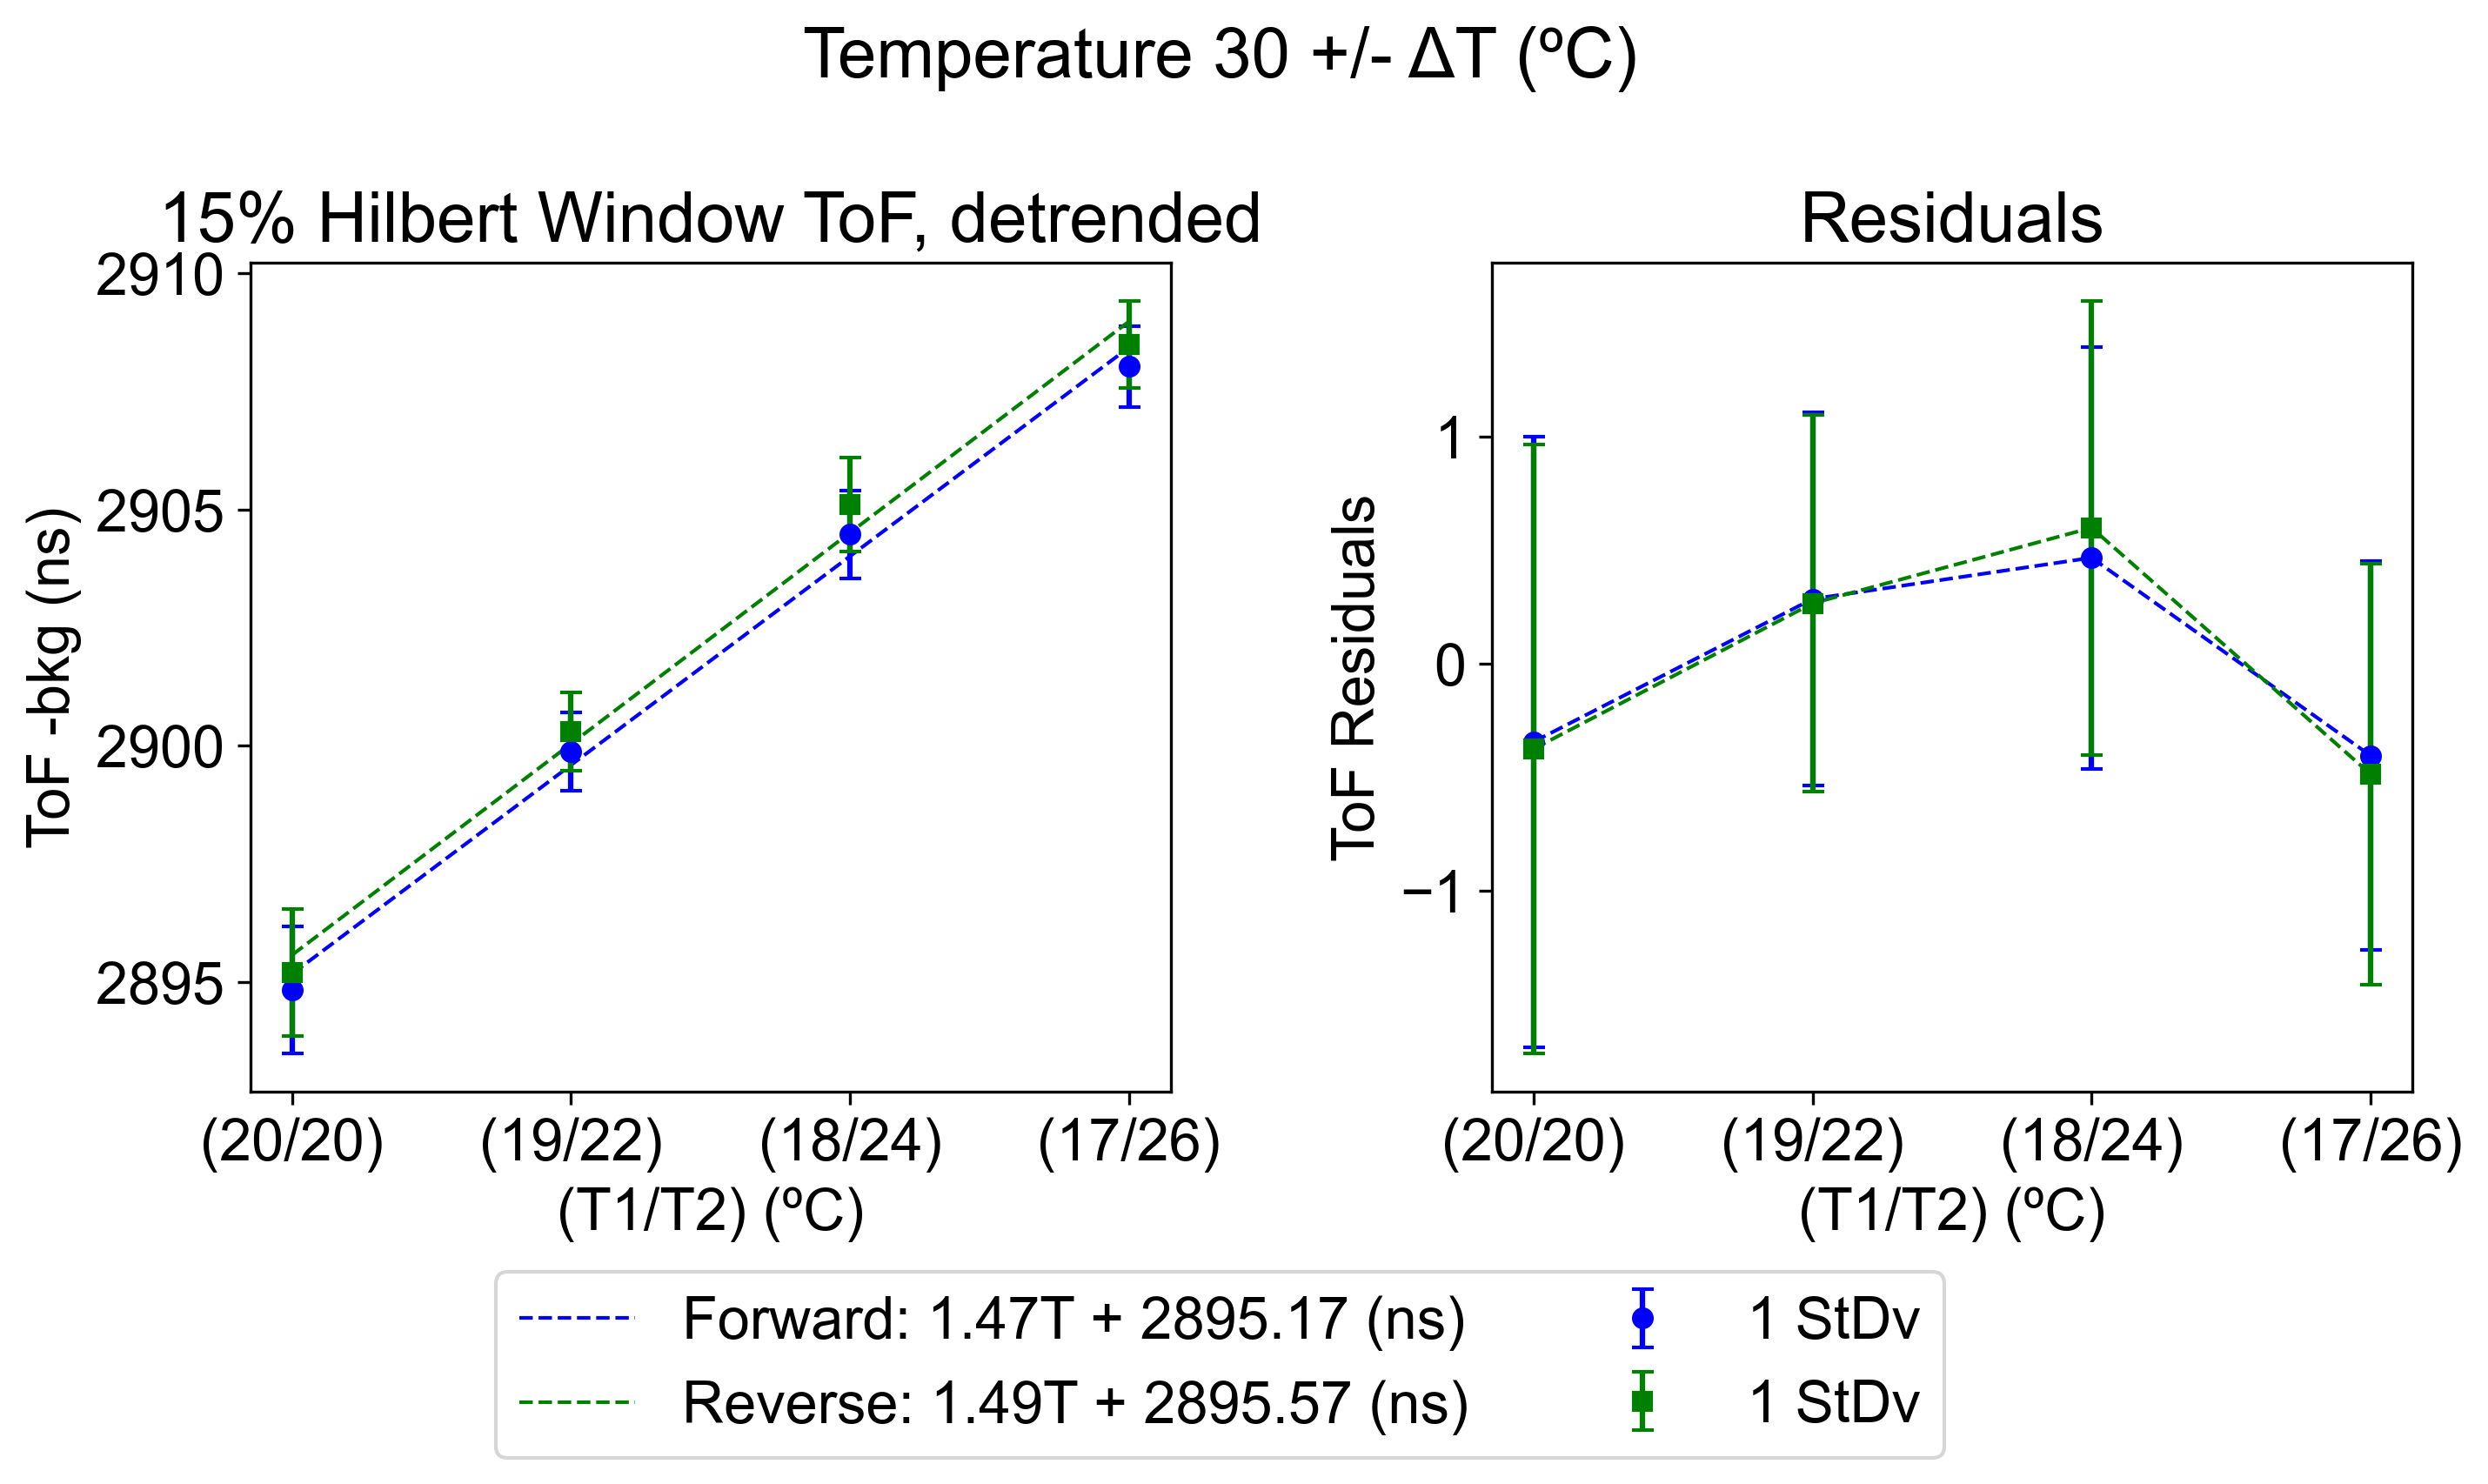

In [153]:
# plot hilbert window tof
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

x_ticks = [f'({20-i}/{20+2*i})' for i in range(4)]

ax[0].plot(d_temps, f_hilbert_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_hilbert_tof_params[0]:.2f}T + {f_hilbert_tof_params[1]:.2f} (ns)')
ax[0].errorbar(d_temps, f_hilbert_tof_arr, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_hilbert_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_hilbert_tof_params[0]:.2f}T + {r_hilbert_tof_params[1]:.2f} (ns)')
ax[0].errorbar(d_temps, r_hilbert_tof_arr, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% Hilbert Window ToF, detrended')
ax[0].set_xlabel('(T1/T2) (ºC)')
ax[0].set_xticks(ticks=d_temps, labels=x_ticks)
ax[0].set_ylabel('ToF -bkg (ns)' )

ax[1].plot(d_temps, f_hilbert_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_hilbert_tof_residuals, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_hilbert_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_hilbert_tof_residuals, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('(T1/T2) (ºC)')
ax[1].set_xticks(ticks=d_temps, labels=x_ticks)
ax[1].set_ylabel('ToF Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)
fig.tight_layout()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
# for i in range(7):
#     mask = (merged_filtered_df['3000.1: CH1 Target'] == 30+i) & \
#            (merged_filtered_df['3000.2: CH2 Target'] == 30-i) & \
#            (merged_filtered_df.index > 750)
diffs=4 
for i in range(diffs):
    mask = (
        (merged_filtered_df['3000.1: CH1 Target'] == 20 - i)
        & (merged_filtered_df['3000.2: CH2 Target'] == 20 + 2*i)
        # & (merged_filtered_df['2010.1: Output Enable'] == 'ON')
        # & (merged_filtered_df['2010.2: Output Enable'] == 'ON')
        # & (merged_filtered_df.index > 755)
    )
    for idx, row in merged_filtered_df.loc[mask].iloc[-10:].iterrows():
        ax[0].plot(
            row['time'],
            row['voltage_transmission_forward'],
            color=cm.viridis(i / (diffs-1)),
            label=f'20 +2ΔT/-ΔT' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
        ax[1].plot(
            row['time'],
            row['voltage_transmission_reverse'],
            color=cm.viridis(i / (diffs-1)),
            label=f'20 +2ΔT/-ΔT' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel('Voltage Normalized')
ax[0].set_title(f'Forward 20 +2ΔT/-ΔT')
# ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
# ax[1].set_ylabel('Voltage Normalized')
ax[1].set_title(f'Reverse 20 +2ΔT/-ΔT')
ax[1].set_xlabel('Time (ns)')


fig.tight_layout()
fig.subplots_adjust(right=0.78)
cax1 = fig.add_axes([0.81, 0.15, 0.02, 0.7])
sm1 = plt.cm.ScalarMappable(cmap=cm.viridis, norm=plt.Normalize(vmin=0, vmax=9))
cbar1 = fig.colorbar(sm1, cax=cax1)
cbar1.ax.set_title('ΔT', pad=10)

cax2 = fig.add_axes([0.91, 0.15, 0.02, 0.7])
sm2 = plt.cm.ScalarMappable(cmap=cm.viridis, norm=plt.Normalize(vmin=20, vmax=21.5))
cbar2 = fig.colorbar(sm2, cax=cax2)
cbar2.ax.set_title('T', pad=10)

In [ ]:
(17+26)/2

### dt individual experiment results

#### gradient 1

In [ ]:
df = merged_filtered_df.iloc[755:1500]

def run_plotter(i=0, keys_=()): plot_temps(i=i, keys_=list(keys_), idx_lable_type='dT')

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

selected_keys = [col for col in df.columns if col.startswith(('Simple_ToF', 'Hilbert_ToF', 'amplitude'))]
selected_keys.sort()
keys = widgets.SelectMultiple(
    options=selected_keys,
    value=tuple([]),
    description='Variable:',
    disabled=False,
)

interact(lambda i, key_: run_plotter(i=i, keys_=list(key_)), i=slider, key_=keys)

In [ ]:
# calculate trends and detrended data for dT experiments
import matplotlib.pyplot as plt
d_temps = range(0, 14, 2)
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []
f_simple_tof_arr, f_simple_tof_err = [], []
r_simple_tof_arr, r_simple_tof_err = [], []
f_hilbert_tof_arr, f_hilbert_tof_err = [], []
r_hilbert_tof_arr, r_hilbert_tof_err = [], []

for i in range(7):
    mask = (
        (merged_filtered_df['3000.1: CH1 Target'] == 30 + i)
        & (merged_filtered_df['3000.2: CH2 Target'] == 30 - i)
        & (merged_filtered_df['2010.1: Output Enable'] == 'ON')
        & (merged_filtered_df['2010.2: Output Enable'] == 'ON')
        & (merged_filtered_df.index > 755)
    )
    filtered_df = merged_filtered_df[mask]
    if filtered_df.empty: 
        print(i)
        continue
    
    f_amp_arr.append(filtered_df[f'amplitude_forward_normalized'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward_normalized'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse_normalized'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse_normalized'].std())
    
    f_simple_tof_arr.append(filtered_df[f'Simple_ToF_forward (ns)'].mean())
    f_simple_tof_err.append(filtered_df[f'Simple_ToF_forward (ns)'].std())
    
    r_simple_tof_arr.append(filtered_df[f'Simple_ToF_reverse (ns)'].mean())
    r_simple_tof_err.append(filtered_df[f'Simple_ToF_reverse (ns)'].std())
    
    f_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_forward (ns)'].mean())
    f_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_forward (ns)'].std())
    
    r_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].mean())
    r_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].std())
    
f_amp_fit = np.polyfit(d_temps, f_amp_arr, 1)
f_amp_fit = f_amp_fit[0] * np.array(d_temps) + f_amp_fit[1]
r_amp_fit = np.polyfit(d_temps, r_amp_arr, 1)
r_amp_fit = r_amp_fit[0] * np.array(d_temps) + r_amp_fit[1]
f_amp_residuals = f_amp_arr - f_amp_fit
r_amp_residuals = r_amp_arr - r_amp_fit

f_simple_tof_fit = np.polyfit(d_temps, f_simple_tof_arr, 1)
f_simple_tof_fit = f_simple_tof_fit[0] * np.array(d_temps) + f_simple_tof_fit[1]
r_simple_tof_fit = np.polyfit(d_temps, r_simple_tof_arr, 1)
r_simple_tof_fit = r_simple_tof_fit[0] * np.array(d_temps) + r_simple_tof_fit[1]
f_simple_tof_residuals = f_simple_tof_arr - f_simple_tof_fit
r_simple_tof_residuals = r_simple_tof_arr - r_simple_tof_fit

f_hilbert_tof_fit = np.polyfit(d_temps, f_hilbert_tof_arr, 1)
f_hilbert_tof_fit = f_hilbert_tof_fit[0] * np.array(d_temps) + f_hilbert_tof_fit[1]
r_hilbert_tof_fit = np.polyfit(d_temps, r_hilbert_tof_arr, 1)
r_hilbert_tof_fit = r_hilbert_tof_fit[0] * np.array(d_temps) + r_hilbert_tof_fit[1]
f_hilbert_tof_residuals = f_hilbert_tof_arr - f_hilbert_tof_fit
r_hilbert_tof_residuals = r_hilbert_tof_arr - r_hilbert_tof_fit

In [ ]:
# plot amplitude
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

ax[0].plot(d_temps, f_amp_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_amp_fit[0]:.2f}T + {f_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_amp_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_amp_fit[0]:.2f}T + {r_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('Peak to Valley Amplitude')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_xticks(ticks=d_temps)
ax[0].set_ylabel('Amplitude normalized -bkg')

ax[1].plot(d_temps, f_amp_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_amp_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_amp_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_amp_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_xticks(ticks=d_temps)
ax[1].set_ylabel('Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

In [ ]:
# plot hilbert window tof
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

ax[0].plot(d_temps, f_hilbert_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_hilbert_tof_fit[0]:.2f}T + {f_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, f_hilbert_tof_arr, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_hilbert_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_hilbert_tof_fit[0]:.2f}T + {r_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, r_hilbert_tof_arr, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% Hilbert Window ToF, detrended')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_xticks(ticks=d_temps)
ax[0].set_ylabel('ToF -bkg (ns)' )

ax[1].plot(d_temps, f_hilbert_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_hilbert_tof_residuals, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_hilbert_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_hilbert_tof_residuals, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_xticks(ticks=d_temps)
ax[1].set_ylabel('ToF Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)
fig.tight_layout()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i in range(7):
    mask = (merged_filtered_df['3000.1: CH1 Target'] == 30+i) & \
           (merged_filtered_df['3000.2: CH2 Target'] == 30-i) & \
           (merged_filtered_df.index > 750)
           
    for idx, row in merged_filtered_df.loc[mask].iloc[-10:].iterrows():
        ax[0].plot(
            row['time'][:1200],
            row['voltage_transmission_forward'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
        ax[1].plot(
            row['time'][:1200],
            row['voltage_transmission_reverse'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel('Voltage Normalized')
ax[0].set_title(f'Forward Tramission for 30 +/- ΔT')
# ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel('Voltage Normalized')
ax[1].set_title(f'Reverse Transmission for 30 +/- ΔT')
ax[1].set_xlabel('Time (ns)')

sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=plt.Normalize(vmin=0, vmax=6))
cbar = fig.colorbar(sm, ax=ax[0], label='ΔT (°C)', pad=0.05)
cbar = fig.colorbar(sm, ax=ax[1], label='ΔT (°C)', pad=0.05)

fig.tight_layout()

#### gradient 1

In [ ]:
df = merged_filtered_df.iloc[755:1500]

def run_plotter(i=0, keys_=()): plot_temps(i=i, keys_=list(keys_), idx_lable_type='dT')

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

selected_keys = [col for col in df.columns if col.startswith(('Simple_ToF', 'Hilbert_ToF', 'amplitude'))]
selected_keys.sort()
keys = widgets.SelectMultiple(
    options=selected_keys,
    value=tuple([]),
    description='Variable:',
    disabled=False,
)

interact(lambda i, key_: run_plotter(i=i, keys_=list(key_)), i=slider, key_=keys)

In [ ]:
# calculate trends and detrended data for dT experiments
import matplotlib.pyplot as plt
d_temps = range(0, 14, 2)
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []
f_simple_tof_arr, f_simple_tof_err = [], []
r_simple_tof_arr, r_simple_tof_err = [], []
f_hilbert_tof_arr, f_hilbert_tof_err = [], []
r_hilbert_tof_arr, r_hilbert_tof_err = [], []

for i in range(7):
    mask = (
        (merged_filtered_df['3000.1: CH1 Target'] == 30 + i)
        & (merged_filtered_df['3000.2: CH2 Target'] == 30 - i)
        & (merged_filtered_df['2010.1: Output Enable'] == 'ON')
        & (merged_filtered_df['2010.2: Output Enable'] == 'ON')
        & (merged_filtered_df.index > 755)
    )
    filtered_df = merged_filtered_df[mask]
    if filtered_df.empty: 
        print(i)
        continue
    
    f_amp_arr.append(filtered_df[f'amplitude_forward_normalized'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward_normalized'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse_normalized'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse_normalized'].std())
    
    f_simple_tof_arr.append(filtered_df[f'Simple_ToF_forward (ns)'].mean())
    f_simple_tof_err.append(filtered_df[f'Simple_ToF_forward (ns)'].std())
    
    r_simple_tof_arr.append(filtered_df[f'Simple_ToF_reverse (ns)'].mean())
    r_simple_tof_err.append(filtered_df[f'Simple_ToF_reverse (ns)'].std())
    
    f_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_forward (ns)'].mean())
    f_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_forward (ns)'].std())
    
    r_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].mean())
    r_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].std())
    
f_amp_fit = np.polyfit(d_temps, f_amp_arr, 1)
f_amp_fit = f_amp_fit[0] * np.array(d_temps) + f_amp_fit[1]
r_amp_fit = np.polyfit(d_temps, r_amp_arr, 1)
r_amp_fit = r_amp_fit[0] * np.array(d_temps) + r_amp_fit[1]
f_amp_residuals = f_amp_arr - f_amp_fit
r_amp_residuals = r_amp_arr - r_amp_fit

f_simple_tof_fit = np.polyfit(d_temps, f_simple_tof_arr, 1)
f_simple_tof_fit = f_simple_tof_fit[0] * np.array(d_temps) + f_simple_tof_fit[1]
r_simple_tof_fit = np.polyfit(d_temps, r_simple_tof_arr, 1)
r_simple_tof_fit = r_simple_tof_fit[0] * np.array(d_temps) + r_simple_tof_fit[1]
f_simple_tof_residuals = f_simple_tof_arr - f_simple_tof_fit
r_simple_tof_residuals = r_simple_tof_arr - r_simple_tof_fit

f_hilbert_tof_fit = np.polyfit(d_temps, f_hilbert_tof_arr, 1)
f_hilbert_tof_fit = f_hilbert_tof_fit[0] * np.array(d_temps) + f_hilbert_tof_fit[1]
r_hilbert_tof_fit = np.polyfit(d_temps, r_hilbert_tof_arr, 1)
r_hilbert_tof_fit = r_hilbert_tof_fit[0] * np.array(d_temps) + r_hilbert_tof_fit[1]
f_hilbert_tof_residuals = f_hilbert_tof_arr - f_hilbert_tof_fit
r_hilbert_tof_residuals = r_hilbert_tof_arr - r_hilbert_tof_fit

In [ ]:
# plot amplitude
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

ax[0].plot(d_temps, f_amp_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_amp_fit[0]:.2f}T + {f_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_amp_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_amp_fit[0]:.2f}T + {r_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('Peak to Valley Amplitude')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_xticks(ticks=d_temps)
ax[0].set_ylabel('Amplitude normalized -bkg')

ax[1].plot(d_temps, f_amp_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_amp_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_amp_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_amp_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_xticks(ticks=d_temps)
ax[1].set_ylabel('Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

In [ ]:
# plot hilbert window tof
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

ax[0].plot(d_temps, f_hilbert_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_hilbert_tof_fit[0]:.2f}T + {f_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, f_hilbert_tof_arr, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_hilbert_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_hilbert_tof_fit[0]:.2f}T + {r_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, r_hilbert_tof_arr, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% Hilbert Window ToF, detrended')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_xticks(ticks=d_temps)
ax[0].set_ylabel('ToF -bkg (ns)' )

ax[1].plot(d_temps, f_hilbert_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_hilbert_tof_residuals, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_hilbert_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_hilbert_tof_residuals, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_xticks(ticks=d_temps)
ax[1].set_ylabel('ToF Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)
fig.tight_layout()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i in range(7):
    mask = (merged_filtered_df['3000.1: CH1 Target'] == 30+i) & \
           (merged_filtered_df['3000.2: CH2 Target'] == 30-i) & \
           (merged_filtered_df.index > 750)
           
    for idx, row in merged_filtered_df.loc[mask].iloc[-10:].iterrows():
        ax[0].plot(
            row['time'][:1200],
            row['voltage_transmission_forward'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
        ax[1].plot(
            row['time'][:1200],
            row['voltage_transmission_reverse'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel('Voltage Normalized')
ax[0].set_title(f'Forward Tramission for 30 +/- ΔT')
# ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel('Voltage Normalized')
ax[1].set_title(f'Reverse Transmission for 30 +/- ΔT')
ax[1].set_xlabel('Time (ns)')

sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=plt.Normalize(vmin=0, vmax=6))
cbar = fig.colorbar(sm, ax=ax[0], label='ΔT (°C)', pad=0.05)
cbar = fig.colorbar(sm, ax=ax[1], label='ΔT (°C)', pad=0.05)

fig.tight_layout()

#### gradient 1

In [ ]:
df = merged_filtered_df.iloc[755:1500]

def run_plotter(i=0, keys_=()): plot_temps(i=i, keys_=list(keys_), idx_lable_type='dT')

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(df)-1,
    step=1,
    description='measurement:',
    continuous_update=False
)

selected_keys = [col for col in df.columns if col.startswith(('Simple_ToF', 'Hilbert_ToF', 'amplitude'))]
selected_keys.sort()
keys = widgets.SelectMultiple(
    options=selected_keys,
    value=tuple([]),
    description='Variable:',
    disabled=False,
)

interact(lambda i, key_: run_plotter(i=i, keys_=list(key_)), i=slider, key_=keys)

In [ ]:
# calculate trends and detrended data for dT experiments
import matplotlib.pyplot as plt
d_temps = range(0, 14, 2)
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []
f_simple_tof_arr, f_simple_tof_err = [], []
r_simple_tof_arr, r_simple_tof_err = [], []
f_hilbert_tof_arr, f_hilbert_tof_err = [], []
r_hilbert_tof_arr, r_hilbert_tof_err = [], []

for i in range(7):
    mask = (
        (merged_filtered_df['3000.1: CH1 Target'] == 30 + i)
        & (merged_filtered_df['3000.2: CH2 Target'] == 30 - i)
        & (merged_filtered_df['2010.1: Output Enable'] == 'ON')
        & (merged_filtered_df['2010.2: Output Enable'] == 'ON')
        & (merged_filtered_df.index > 755)
    )
    filtered_df = merged_filtered_df[mask]
    if filtered_df.empty: 
        print(i)
        continue
    
    f_amp_arr.append(filtered_df[f'amplitude_forward_normalized'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward_normalized'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse_normalized'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse_normalized'].std())
    
    f_simple_tof_arr.append(filtered_df[f'Simple_ToF_forward (ns)'].mean())
    f_simple_tof_err.append(filtered_df[f'Simple_ToF_forward (ns)'].std())
    
    r_simple_tof_arr.append(filtered_df[f'Simple_ToF_reverse (ns)'].mean())
    r_simple_tof_err.append(filtered_df[f'Simple_ToF_reverse (ns)'].std())
    
    f_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_forward (ns)'].mean())
    f_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_forward (ns)'].std())
    
    r_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].mean())
    r_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].std())
    
f_amp_fit = np.polyfit(d_temps, f_amp_arr, 1)
f_amp_fit = f_amp_fit[0] * np.array(d_temps) + f_amp_fit[1]
r_amp_fit = np.polyfit(d_temps, r_amp_arr, 1)
r_amp_fit = r_amp_fit[0] * np.array(d_temps) + r_amp_fit[1]
f_amp_residuals = f_amp_arr - f_amp_fit
r_amp_residuals = r_amp_arr - r_amp_fit

f_simple_tof_fit = np.polyfit(d_temps, f_simple_tof_arr, 1)
f_simple_tof_fit = f_simple_tof_fit[0] * np.array(d_temps) + f_simple_tof_fit[1]
r_simple_tof_fit = np.polyfit(d_temps, r_simple_tof_arr, 1)
r_simple_tof_fit = r_simple_tof_fit[0] * np.array(d_temps) + r_simple_tof_fit[1]
f_simple_tof_residuals = f_simple_tof_arr - f_simple_tof_fit
r_simple_tof_residuals = r_simple_tof_arr - r_simple_tof_fit

f_hilbert_tof_fit = np.polyfit(d_temps, f_hilbert_tof_arr, 1)
f_hilbert_tof_fit = f_hilbert_tof_fit[0] * np.array(d_temps) + f_hilbert_tof_fit[1]
r_hilbert_tof_fit = np.polyfit(d_temps, r_hilbert_tof_arr, 1)
r_hilbert_tof_fit = r_hilbert_tof_fit[0] * np.array(d_temps) + r_hilbert_tof_fit[1]
f_hilbert_tof_residuals = f_hilbert_tof_arr - f_hilbert_tof_fit
r_hilbert_tof_residuals = r_hilbert_tof_arr - r_hilbert_tof_fit

In [ ]:
# plot amplitude
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

ax[0].plot(d_temps, f_amp_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_amp_fit[0]:.2f}T + {f_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_amp_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_amp_fit[0]:.2f}T + {r_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('Peak to Valley Amplitude')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_xticks(ticks=d_temps)
ax[0].set_ylabel('Amplitude normalized -bkg')

ax[1].plot(d_temps, f_amp_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_amp_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_amp_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_amp_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_xticks(ticks=d_temps)
ax[1].set_ylabel('Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

In [ ]:
# plot hilbert window tof
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Temperature 30 +/- ΔT (ºC)')

ax[0].plot(d_temps, f_hilbert_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_hilbert_tof_fit[0]:.2f}T + {f_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, f_hilbert_tof_arr, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_hilbert_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_hilbert_tof_fit[0]:.2f}T + {r_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, r_hilbert_tof_arr, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% Hilbert Window ToF, detrended')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_xticks(ticks=d_temps)
ax[0].set_ylabel('ToF -bkg (ns)' )

ax[1].plot(d_temps, f_hilbert_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_hilbert_tof_residuals, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_hilbert_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_hilbert_tof_residuals, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_xticks(ticks=d_temps)
ax[1].set_ylabel('ToF Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)
fig.tight_layout()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i in range(7):
    mask = (merged_filtered_df['3000.1: CH1 Target'] == 30+i) & \
           (merged_filtered_df['3000.2: CH2 Target'] == 30-i) & \
           (merged_filtered_df.index > 750)
           
    for idx, row in merged_filtered_df.loc[mask].iloc[-10:].iterrows():
        ax[0].plot(
            row['time'][:1200],
            row['voltage_transmission_forward'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
        ax[1].plot(
            row['time'][:1200],
            row['voltage_transmission_reverse'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
ax[0].set_xlabel('Time (ns)')
ax[0].set_ylabel('Voltage Normalized')
ax[0].set_title(f'Forward Tramission for 30 +/- ΔT')
# ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax[1].set_ylabel('Voltage Normalized')
ax[1].set_title(f'Reverse Transmission for 30 +/- ΔT')
ax[1].set_xlabel('Time (ns)')

sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=plt.Normalize(vmin=0, vmax=6))
cbar = fig.colorbar(sm, ax=ax[0], label='ΔT (°C)', pad=0.05)
cbar = fig.colorbar(sm, ax=ax[1], label='ΔT (°C)', pad=0.05)

fig.tight_layout()

In [ ]:
# calculate trends and detrended data for dT experiments
import matplotlib.pyplot as plt
d_temps = range(0, 14, 2)
f_amp_arr, f_amp_err = [], []
r_amp_arr, r_amp_err = [], []
f_simple_tof_arr, f_simple_tof_err = [], []
r_simple_tof_arr, r_simple_tof_err = [], []
f_hilbert_tof_arr, f_hilbert_tof_err = [], []
r_hilbert_tof_arr, r_hilbert_tof_err = [], []

for i in range(7):
    mask = (
        (merged_filtered_df['3000.1: CH1 Target'] == 30 + i)
        & (merged_filtered_df['3000.2: CH2 Target'] == 30 - i)
        & (merged_filtered_df['2010.1: Output Enable'] == 'ON')
        & (merged_filtered_df['2010.2: Output Enable'] == 'ON')
        & (merged_filtered_df.index > 755)
    )
    filtered_df = merged_filtered_df[mask]
    if filtered_df.empty: 
        print(i)
        continue
    
    f_amp_arr.append(filtered_df[f'amplitude_forward_normalized'].mean())
    f_amp_err.append(filtered_df[f'amplitude_forward_normalized'].std())
    
    r_amp_arr.append(filtered_df[f'amplitude_reverse_normalized'].mean())
    r_amp_err.append(filtered_df[f'amplitude_reverse_normalized'].std())
    
    f_simple_tof_arr.append(filtered_df[f'Simple_ToF_forward (ns)'].mean())
    f_simple_tof_err.append(filtered_df[f'Simple_ToF_forward (ns)'].std())
    
    r_simple_tof_arr.append(filtered_df[f'Simple_ToF_reverse (ns)'].mean())
    r_simple_tof_err.append(filtered_df[f'Simple_ToF_reverse (ns)'].std())
    
    f_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_forward (ns)'].mean())
    f_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_forward (ns)'].std())
    
    r_hilbert_tof_arr.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].mean())
    r_hilbert_tof_err.append(filtered_df[f'Hilbert_ToF_reverse (ns)'].std())
    
f_amp_fit = np.polyfit(d_temps, f_amp_arr, 1)
f_amp_fit = f_amp_fit[0] * np.array(d_temps) + f_amp_fit[1]
r_amp_fit = np.polyfit(d_temps, r_amp_arr, 1)
r_amp_fit = r_amp_fit[0] * np.array(d_temps) + r_amp_fit[1]
f_amp_residuals = f_amp_arr - f_amp_fit
r_amp_residuals = r_amp_arr - r_amp_fit

f_simple_tof_fit = np.polyfit(d_temps, f_simple_tof_arr, 1)
f_simple_tof_fit = f_simple_tof_fit[0] * np.array(d_temps) + f_simple_tof_fit[1]
r_simple_tof_fit = np.polyfit(d_temps, r_simple_tof_arr, 1)
r_simple_tof_fit = r_simple_tof_fit[0] * np.array(d_temps) + r_simple_tof_fit[1]
f_simple_tof_residuals = f_simple_tof_arr - f_simple_tof_fit
r_simple_tof_residuals = r_simple_tof_arr - r_simple_tof_fit

f_hilbert_tof_fit = np.polyfit(d_temps, f_hilbert_tof_arr, 1)
f_hilbert_tof_fit = f_hilbert_tof_fit[0] * np.array(d_temps) + f_hilbert_tof_fit[1]
r_hilbert_tof_fit = np.polyfit(d_temps, r_hilbert_tof_arr, 1)
r_hilbert_tof_fit = r_hilbert_tof_fit[0] * np.array(d_temps) + r_hilbert_tof_fit[1]
f_hilbert_tof_residuals = f_hilbert_tof_arr - f_hilbert_tof_fit
r_hilbert_tof_residuals = r_hilbert_tof_arr - r_hilbert_tof_fit

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Average Temperature 10-55ºC')

ax[0].plot(d_temps, f_amp_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_amp_fit[0]:.2f}T + {f_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, f_amp_arr, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_amp_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_amp_fit[0]:.2f}T + {r_amp_fit[1]:.2f}')
ax[0].errorbar(d_temps, r_amp_arr, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('Peak to Valley Amplitude')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_ylabel('Amplitude normalized')

ax[1].plot(d_temps, f_amp_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_amp_residuals, yerr=f_amp_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_amp_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_amp_residuals, yerr=r_amp_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_ylabel('Residuals normalized')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Average Temperature 10-55ºC')

ax[0].plot(d_temps, f_simple_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_simple_tof_fit[0]:.2f}T + {f_simple_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, f_simple_tof_arr, yerr=f_simple_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_simple_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_simple_tof_fit[0]:.2f}T + {r_simple_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, r_simple_tof_arr, yerr=r_simple_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% threshold ToF')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_ylabel('ToF (ns)' )

ax[1].plot(d_temps, f_simple_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_simple_tof_residuals, yerr=f_simple_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_simple_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_simple_tof_residuals, yerr=r_simple_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_ylabel('ToF (ns) Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)

fig.tight_layout()

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle('Average Temperature 10-55ºC')

ax[0].plot(d_temps, f_hilbert_tof_fit, color='blue', linewidth=1, linestyle='--', label=f'Forward: {f_hilbert_tof_fit[0]:.2f}T + {f_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, f_hilbert_tof_arr, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3, label=f'1 StDv')
ax[0].plot(d_temps, r_hilbert_tof_fit, color='green', linewidth=1, linestyle='--', label=f'Reverse: {r_hilbert_tof_fit[0]:.2f}T + {r_hilbert_tof_fit[1]:.2f} (ns)')
ax[0].errorbar(d_temps, r_hilbert_tof_arr, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3, label=f'1 StDv')
ax[0].set_title('15% Hilbert Window ToF')
ax[0].set_xlabel('ΔT (ºC)')
ax[0].set_ylabel('ToF (ns)' )

ax[1].plot(d_temps, f_hilbert_tof_residuals, color='blue', linewidth=1, linestyle='--')
ax[1].errorbar(d_temps, f_hilbert_tof_residuals, yerr=f_hilbert_tof_err, fmt='o', markersize=5, color='blue', ecolor='blue', capsize=3)
ax[1].plot(d_temps, r_hilbert_tof_residuals, color='green', linewidth=1, linestyle='--',)
ax[1].errorbar(d_temps, r_hilbert_tof_residuals, yerr=r_hilbert_tof_err, fmt='s', markersize=5, color='green', ecolor='green', capsize=3,)
ax[1].set_title('Residuals')
ax[1].set_xlabel('ΔT (ºC)')
ax[1].set_ylabel('ToF (ns) Residuals')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.14), ncol=2)
fig.tight_layout()

In [ ]:
fig, ax = plt.subplots(2, figsize=(6, 8))
for i in range(7):
    mask = (merged_filtered_df['3000.1: CH1 Target'] == 30+i) & \
           (merged_filtered_df['3000.2: CH2 Target'] == 30-i) & \
           (merged_filtered_df.index > 750)
           
    for idx, row in merged_filtered_df.loc[mask].iloc[-10:].iterrows():
        ax[0].plot(
            row['time'][:1200],
            row['voltage_transmission_forward'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
        ax[1].plot(
            row['time'][:1200],
            row['voltage_transmission_reverse'][:1200],
            color=cm.viridis(i / 7),
            label=f'30 +/- {i}' if idx == merged_filtered_df.loc[mask].index[-1] else None
        )
    ax[0].set_xlabel('Time')
    ax[0].set_ylabel('Voltage')
    ax[0].set_title(f'Forward Tramission for mean temp 30')
    ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax[1].set_xlabel('Time')
    ax[1].set_ylabel('Voltage')
    ax[1].set_title(f'Reverse Transmission for mean temp 30')
    
    fig.tight_layout()

## Stat tests

### PCA

In [ ]:
import warnings
warnings.filterwarnings("ignore")

### for waveforms

Normally, data going into sklearn modules should have shape (n_samples, n_features). In the case of spectral data, each scan is a sample, and each point in time is a feature.

However in this case, we normalize the flattened data because we do not want to erase the effects of amplitude changes between scans.

In [ ]:
merged_filtered_df.columns

In [ ]:
merged_filtered_copy = merged_filtered_df.drop(['voltage_transmission_forward', 
                                                'voltage_transmission_reverse',
                                                'time', 
                                                '3034.2: Peltier Polarity',
                                                '3034.2: Peltier Polarity',
                                                '1200.1: Temperature is Stable',
                                                'Time_str',
                                                '2010.1: Output Enable',
                                                '2010.2: Output Enable',
                                                ], axis=1).copy()
merged_filtered_copy.tail()

In [ ]:
np.stack(merged_filtered_copy.values)

In [ ]:
merged_filtered_copy

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
scaler = Pipeline([('standard', StandardScaler()), ('minmax', MinMaxScaler())]) # scaler inputs are in format 
signal_keys = ['voltage_transmission_forward', 'voltage_transmission_reverse']

# X =np.stack( [ np.stack(merged_filtered_df[key].values) for key in signal_keys ])

data_rescaled = scaler.fit_transform(X.reshape(-1, 1)).reshape(X.shape)
data_rescaled.shape

We do not usually need all components to capture trends in the data. Almost all variance is explained in the first 6 components

In [ ]:
from  sklearn.decomposition import PCA
from tqdm import tqdm

components=10
pca = PCA(n_components=components)
transformed = pca.fit_transform(data_rescaled.reshape(-1, data_rescaled.shape[-1])).reshape(data_rescaled.shape[0], data_rescaled.shape[1], components)

fig, ax = plt.subplots()
x = np.arange(1, components + 1)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

ax.plot(x, explained, marker='o', label='explained variance of component')
for xi, ex in zip(x, explained):  ax.text(xi, ex + 0.02, f'{ex:.2%}', ha='center', va='bottom', fontsize=8)

ax.plot(x, cumulative, marker='s', linestyle='--', label='cumulative explained variance')
for xi, cum in zip(x, cumulative):  ax.text(xi, cum + 0.02, f'{cum:.2%}', ha='center', va='bottom', fontsize=8)

ax.set_title('Explained Variance of Principal Components')
ax.set_xlabel('Principal Component Number')
ax.set_ylabel('Explained Variance Ratio')
ax.set_ylim(0, 1.25)
ax.legend()

In [ ]:
import math
import matplotlib.colors as mcolors

def plot_PCs(transformed, pc_s, color_by_column, marker_categories=0, skip_=10):
    '''Plot scatter plots of the first 6 principal components'''
    color_vals = merged_filtered_df[color_by_column].values
    cvals = color_vals[::skip_]
    norm = mcolors.Normalize(vmin=cvals.min(), vmax=cvals.max())  # fixed range, built once
    cmap = plt.cm.viridis

    markers_ = ['o','^','v', 's','x', '_','.', '+',  '*', '<', '>', 'p', 'h']
        
    combos = math.comb(pc_s, 2)
    x_, y_ = int(combos**0.5), math.ceil(combos/int(combos**0.5))
    fig, ax = plt.subplots(x_, y_, figsize=(3*y_+0.5, 3*x_))
    fig.suptitle(f'PCA Scatter Plots comparing First {pc_s} Principal Components, colored by {color_by_column} value')
    ax = ax.flatten()
    if combos < x_*y_:
        for a in ax[-(x_*y_-combos):]: fig.delaxes(a)  # remove any extra axes if the grid is larger than the number of combinations

    ind = 0
    for i in range(pc_s):
        for j in range(i+1, pc_s):
            
            if marker_categories:
                for m,label in enumerate(marker_categories):
                    ax[ind].scatter(transformed[m, :, i][::skip_], transformed[m, :, j][::skip_], 
                                     marker=markers_[m], s=y_*10, linewidths=0.25,
                                     edgecolors=cmap(norm(color_vals[::skip_])),
                                     facecolors='none', label=label)
                    
                fig.legend(labels=marker_categories, loc='lower center', ncol=len(marker_categories), bbox_to_anchor=(0.5, -0.05))
                    
            else: ax[ind].scatter(transformed[:, i][::skip_], transformed[:, j][::skip_], marker='o', s=y_*10, c=color_vals[::skip_], cmap=cmap, norm=norm)

            ax[ind].set_title(f'x:PC{i+1}, y:PC{j+1}')
            ind += 1
            
    fig.tight_layout()
    # carve out space on the right, then place a colorbar axes there
    fig.subplots_adjust(right=0.90)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height] in figure coords
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, label=f'{color_by_column}')

In [ ]:
merged_filtered_df.columns # select which column to color by

In [ ]:
plot_PCs(transformed=transformed, 
         pc_s=6,
         color_by_column='diff',
         marker_categories=['voltage_transmission_forward', 'voltage_transmission_reverse'])

In [ ]:
merged_filtered_df['amplitude_diff'] = merged_filtered_df['amplitude_forward']-merged_filtered_df['amplitude_reverse']

In [ ]:
plt.hist(merged_filtered_df['amplitude_diff'], bins=30, color='blue', alpha=0.7)

In [ ]:
plot_PCs(transformed=transformed, 
         pc_s=6,
         color_by_column='amplitude_diff',
         marker_categories=['voltage_transmission_forward', 'voltage_transmission_reverse'],
         skip_=10)